In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('tmdb_movies.csv', encoding='latin1')

In [3]:
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,director,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,5562,6.5,2015,137999939.3,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action,6185,7.1,2015,137999939.3,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,119,Adventure,2480,6.3,2015,101199955.5,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,136,Action,5292,7.5,2015,183999919.0,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,137,Action,2947,7.3,2015,174799923.1,1.385749e+09


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3854 entries, 0 to 3853
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3854 non-null   int64  
 1   imdb_id         3854 non-null   object 
 2   popularity      3854 non-null   float64
 3   budget          3854 non-null   int64  
 4   revenue         3854 non-null   int64  
 5   original_title  3854 non-null   object 
 6   cast            3850 non-null   object 
 7   director        3853 non-null   object 
 8   runtime         3854 non-null   int64  
 9   genres          3854 non-null   object 
 10  vote_count      3854 non-null   int64  
 11  vote_average    3854 non-null   float64
 12  release_year    3854 non-null   int64  
 13  budget_adj      3854 non-null   float64
 14  revenue_adj     3854 non-null   float64
dtypes: float64(4), int64(6), object(5)
memory usage: 451.8+ KB


In [5]:
df.describe().astype('int')

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,3854,3854,3854,3854,3854,3854,3854,3854,3854,3854
mean,39896,1,37208886,107686487,109,527,6,2001,44244781,137064503
std,67220,1,42206108,176539423,19,879,0,11,44806745,216111468
min,5,0,1,2,15,10,2,1960,0,2
25%,6073,0,10000000,13600032,95,71,5,1995,13090528,18357350
50%,11321,0,24000000,44800002,106,204,6,2004,30016111,61730679
75%,38578,1,50000000,124212540,119,580,6,2010,60613069,163257654
max,417859,32,425000000,2781505847,338,9767,8,2015,425000000,2827123750


In [6]:
df.isnull()

,id,imdb_id,popularity,budget,revenue,original_title,cast,director,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3849,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3850,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3851,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3852,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df[df.isnull().any(axis=1)]

,id,imdb_id,popularity,budget,revenue,original_title,cast,director,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj
1096,15467,tt1105733,0.147657,4180000,11000000,Kismat Konnection,Shahid Kapoor|Vidya Balan|Juhi Chawla|Om Puri|...,NaN,153,Drama,11,5.8,2008,4.233448e+06,1.114065e+07
1421,21925,tt0145937,0.193929,3000000,13308,Naqoyqatsi,NaN,Godfrey Reggio,89,Documentary,20,6.0,2002,3.636784e+06,1.613277e+04
1645,126509,tt2247692,0.075043,2500000,33400000,2016: Obama's America,NaN,Dinesh D'Souza|John Sullivan,87,Documentary,11,4.7,2012,2.374361e+06,3.172146e+07
2751,22887,tt0914809,0.065543,6000,6000,Loose Change: Final Cut,NaN,Dylan Avery,129,Documentary,12,5.1,2007,6.310011e+03,6.310011e+03
3465,24348,tt0095895,0.168545,2500000,589244,Powaqqatsi,NaN,Godfrey Reggio,99,Documentary,18,7.2,1988,4.609728e+06,1.086502e+06


In [8]:
#Top 10 movies with revenue
top_movies = df.groupby('original_title')['revenue'].sum().sort_values(ascending = False).astype('int64').head(10)
top_movies.to_frame()

,revenue
original_title,
Avatar,2781505847
Star Wars: The Force Awakens,2068178225
Titanic,1845034188
The Avengers,1568080742
Jurassic World,1513528810
Furious 7,1506249360
Avengers: Age of Ultron,1405035767
Harry Potter and the Deathly Hallows: Part 2,1327817822
Frozen,1274219009


<Axes: ylabel='original_title'>

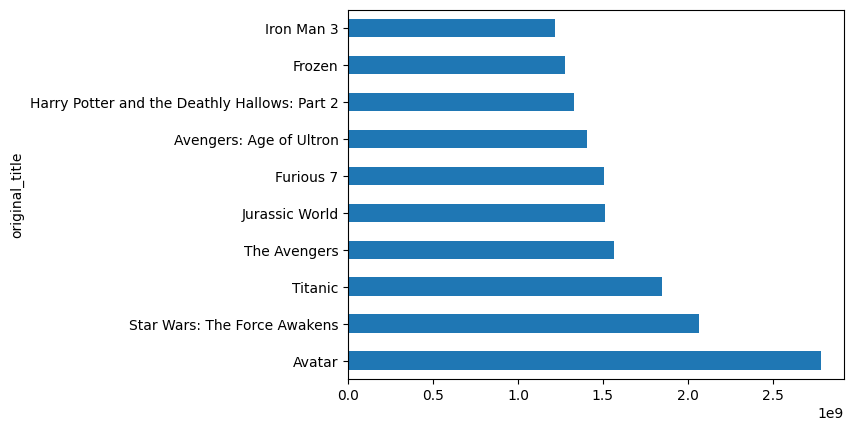

In [9]:
top_movies.plot(kind = 'barh')

<Axes: >

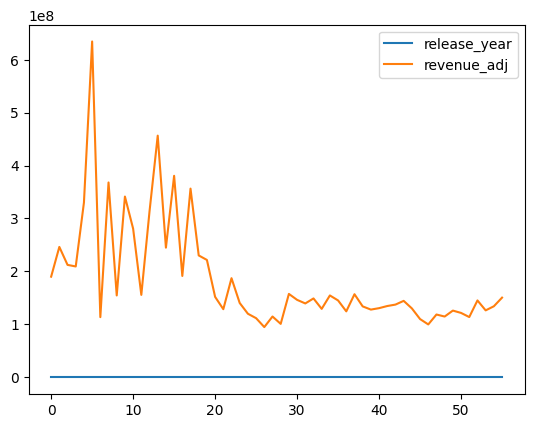

In [10]:
year_revenue = df.groupby("release_year")['revenue_adj'].mean().astype('int64').to_frame().reset_index()
year_revenue.plot()

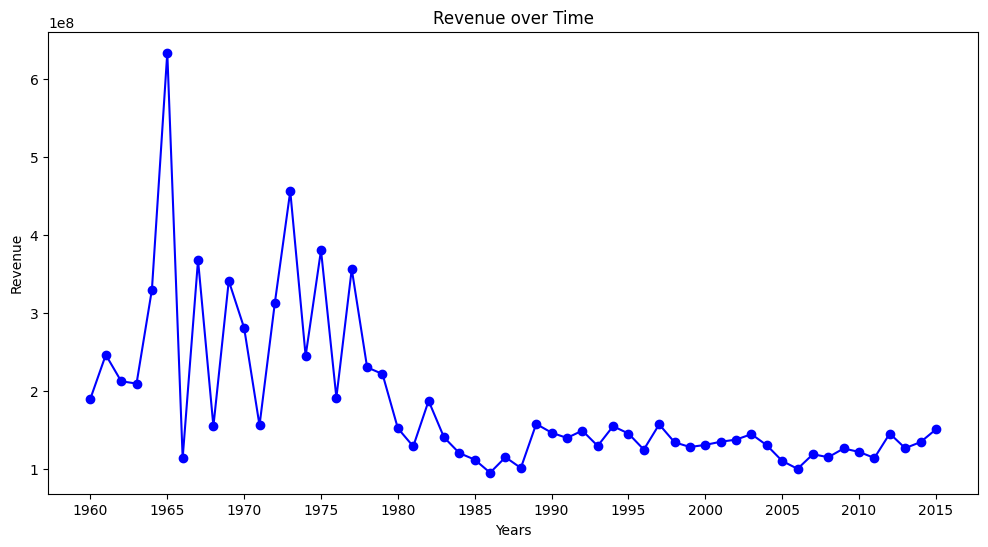

In [11]:
# o ==> دائرة
# s ==> مربع
import matplotlib.pyplot as plt

custom_year = year_revenue['release_year'][::5]
plt.figure(figsize=(12, 6))
plt.plot(year_revenue['release_year'], year_revenue['revenue_adj'], marker='o', color='b')
plt.title('Revenue over Time')
plt.xlabel('Years')
plt.ylabel('Revenue')
plt.xticks(custom_year)
plt.show()

In [12]:
genres = df[df['genres'].isin(['Action', 'Comedy', 'Drama'])]

In [18]:
genresRev = genres.groupby('genres')['revenue_adj'].mean().to_frame().reset_index()

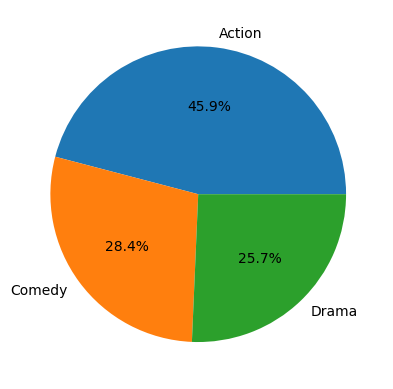

In [19]:
plt.pie(genresRev['revenue_adj'], labels = genresRev['genres'], autopct = '%1.1f%%' )
plt.show()

<Axes: ylabel='Frequency'>

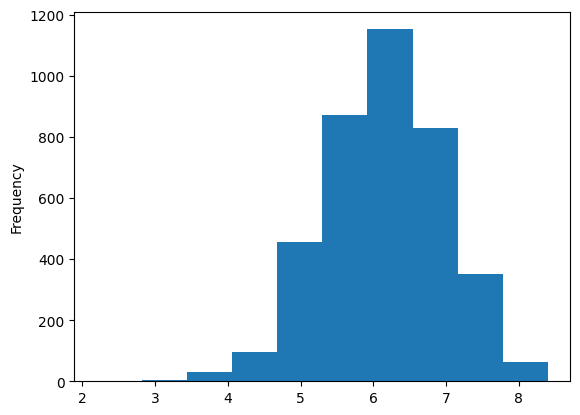

In [20]:
df['vote_average'].plot(kind ='hist')

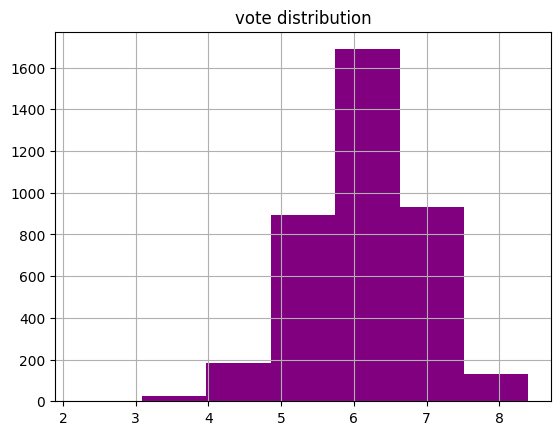

In [24]:
plt.hist(df['vote_average'], bins =7, color = 'purple', alpha = 0.7)
plt.grid(True)
plt.title('vote distribution')
plt.show()

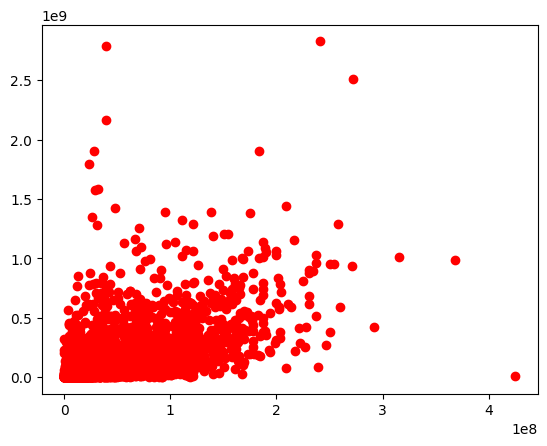

In [25]:
plt.scatter(df['budget_adj'], df['revenue_adj'], color='red' )

In [26]:
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,director,runtime,genres,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,5562,6.5,2015,137999939.3,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action,6185,7.1,2015,137999939.3,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,119,Adventure,2480,6.3,2015,101199955.5,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,136,Action,5292,7.5,2015,183999919.0,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,137,Action,2947,7.3,2015,174799923.1,1.385749e+09


In [28]:
num = df.select_dtypes(include  = 'number')
num

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,32.985763,150000000,1513528810,124,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,28.419936,150000000,378436354,120,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,13.112507,110000000,295238201,119,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,11.173104,200000000,2068178225,136,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,9.335014,190000000,1506249360,137,2947,7.3,2015,1.747999e+08,1.385749e+09
...,...,...,...,...,...,...,...,...,...,...
3849,396,0.670274,7500000,33736689,131,74,7.5,1966,5.038511e+07,2.266436e+08
3850,5780,0.402730,3000000,13000000,128,46,6.3,1966,2.015404e+07,8.733419e+07
3851,6644,0.395668,4653000,6000000,120,36,6.9,1966,3.125892e+07,4.030809e+07
3852,5923,0.299911,12000000,20000000,182,28,7.0,1966,8.061618e+07,1.343603e+08


In [29]:
num_data = df[['revenue_adj', 'budget_adj', 'vote_average', 'vote_count', 'runtime']]
corr = num_data.corr()
corr

,revenue_adj,budget_adj,vote_average,vote_count,runtime
revenue_adj,1.000000,0.570416,0.267134,0.654685,0.280558
budget_adj,0.570416,1.000000,0.037045,0.497942,0.333963
vote_average,0.267134,0.037045,1.000000,0.387396,0.352009
vote_count,0.654685,0.497942,0.387396,1.000000,0.273803
runtime,0.280558,0.333963,0.352009,0.273803,1.000000


Text(0.5, 1.0, 'Revenue Relationships')

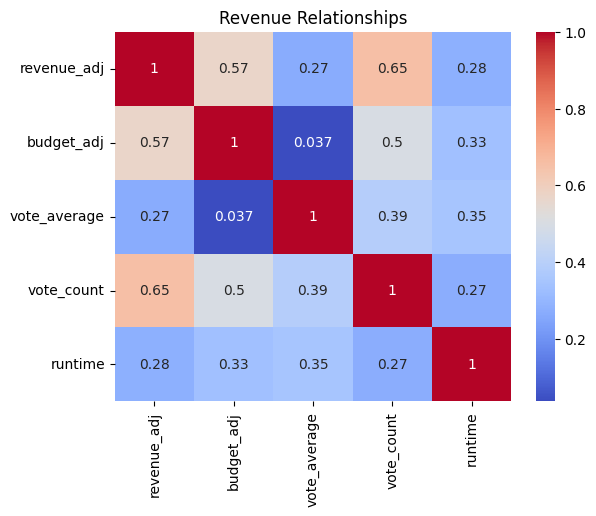

In [32]:
import seaborn as sns
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Revenue Relationships')